# NBM v5 MaxT/MinT Verification — Parquet Edition
Point verification of NBM QMD probabilistic temperature forecasts for a NWS CWA.
Reads from pre-aggregated parquet files — no GRIB reading or observation downloading required.

In [17]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import date

In [54]:
# ── Study period ──────────────────────────────────────────────────────────
START_DATE = date(2026, 3, 1)
END_DATE   = date(2026, 5, 15)

# ── CWA ───────────────────────────────────────────────────────────────────
CWA = "OKX"

# ── Data root ─────────────────────────────────────────────────────────────
PARQUET_ROOT = Path(r"N:\data\nbm_para\parquet\maxtmint\point")

# ── Per-station distribution histogram: lead day to display ──────────────
LEAD_DAY = 1

# ── Probabilistic verification ────────────────────────────────────────────
SKIP_PERCS  = {100}                    # p=100 excluded from reliability diagram
PROB_BINS   = np.linspace(0, 1, 11)   # reliability diagram bin edges
BIN_CENTERS = 0.5 * (PROB_BINS[:-1] + PROB_BINS[1:])

# ── Time-matching diagnostic (Section 4) ─────────────────────────────────
DIAG_LEAD      = 1
DIAG_INIT_HOUR = 12        # restrict to one init cycle (0, 12, or None = all)
# DIAG_STATION / DIAG_START / DIAG_END are auto-selected in Section 4

## 1. Station Metadata
Load station metadata and filter to the target CWA using the `WFO` column.

In [40]:
import requests

stations = pd.read_csv(PARQUET_ROOT / "metadata" / "stations_maxtmint.csv")
cwa_stations = stations[stations['WFO'] == CWA].reset_index(drop=True)

# ── Synoptic Metadata API: get ICAO STID (e.g. KJFK) for each station ────
_TOKEN = "a2386b75ecbc4c2784db1270695dde73"
_resp = requests.get(
    "https://api.synopticdata.com/v2/stations/metadata",
    params={"token": _TOKEN, "cwa": CWA},
    timeout=30,
)
_resp.raise_for_status()
_syn_stations = _resp.json().get("STATION", [])

# Build lookup DataFrame; exclude network-prefixed identifiers (COOP*, USC00*)
# that are worse than the original GHCN id as display labels.
# Priority within remaining identifiers:
#   0 — ICAO  (K + exactly 3 alpha chars, e.g. KJFK)
#   1 — other alphanumeric  (e.g. NRWC3, CHAN4)
#   2 — purely numeric
# Within the same tier, prefer the shorter identifier.
_EXCLUDE_PREFIXES = ("COOP", "USC00")

_syn_df = pd.DataFrame([
    {"stid": s["STID"],
     "syn_lat": round(float(s["LATITUDE"]), 3),
     "syn_lon": round(float(s["LONGITUDE"]), 3)}
    for s in _syn_stations
    if not s["STID"].startswith(_EXCLUDE_PREFIXES)
])
_syn_df["_rank"] = _syn_df["stid"].map(
    lambda x: 0 if (len(x) == 4 and x.startswith("K") and x[1:].isalpha())
              else (1 if any(c.isalpha() for c in x) else 2)
)
_syn_df["_len"] = _syn_df["stid"].str.len()
_syn_df = (
    _syn_df.sort_values(["_rank", "_len"])
    .drop_duplicates(subset=["syn_lat", "syn_lon"], keep="first")
    .drop(columns=["_rank", "_len"])
)

# Rename original numeric/ghcn column; match to preferred STID by rounded coordinates
cwa_stations = cwa_stations.rename(columns={"stid": "ghcn"})
cwa_stations["_lat3"] = cwa_stations["lat"].round(3)
cwa_stations["_lon3"] = cwa_stations["lon"].round(3)
cwa_stations = (
    cwa_stations
    .merge(_syn_df, left_on=["_lat3", "_lon3"], right_on=["syn_lat", "syn_lon"], how="left")
    .drop(columns=["_lat3", "_lon3", "syn_lat", "syn_lon"])
)
# Fall back to ghcn id if no Synoptic match found
cwa_stations["stid"] = cwa_stations["stid"].fillna(cwa_stations["ghcn"].astype(str))

# Deduplicate stations at the same coordinates: prefer ICAO > alphanumeric > numeric/USC
def _stid_sort_key(s):
    if len(s) == 4 and s.startswith("K") and s[1:].isalpha():
        return (0, len(s))
    if s.startswith(("USC00",)) or s.isdigit():
        return (2, len(s))
    return (1, len(s))

cwa_stations["_sort"] = cwa_stations["stid"].map(_stid_sort_key)
cwa_stations = (
    cwa_stations.sort_values("_sort")
    .drop_duplicates(subset=["lat", "lon"], keep="first")
    .drop(columns="_sort")
)

# Reorder: stid first, then ghcn
cols = ["stid", "ghcn"] + [c for c in cwa_stations.columns if c not in ("stid", "ghcn")]
cwa_stations = cwa_stations[cols].reset_index(drop=True)

n_icao = cwa_stations["stid"].str.match(r'^K[A-Z]{3}$').sum()
print(f"{CWA}: {len(cwa_stations)} stations | {n_icao} with ICAO stid | "
      f"{len(cwa_stations) - n_icao} falling back to shorter/GHCN id")
cwa_stations[["stid", "ghcn", "name", "lat", "lon", "WFO"]]


OKX: 41 stations | 12 with ICAO stid | 29 falling back to shorter/GHCN id


,stid,ghcn,name,lat,lon,WFO
0,KGON,14707,GROTON NEW LONDON AP,41.3279,-72.0489,OKX
1,KFRG,54787,FARMINGDALE REPUBLIC AP,40.7344,-73.4164,OKX
2,KFOK,14719,WESTHAMPTON GABRESKI AP,40.8506,-72.6193,OKX
3,KSWF,14714,STEWART FIELD,41.5000,-74.1000,OKX
4,KMGJ,04789,MONTGOMERY ORANGE COUNTY AP,41.5091,-74.2646,OKX
5,KJRB,KJRB,PORT AUTH DOWNTN MANHATTAN WALL ST HEL,40.7012,-74.0090,OKX
6,KJFK,74486,JFK INTERNATIONAL AIRPORT,40.6392,-73.7639,OKX
7,KCDW,54743,CALDWELL ESSEX COUNTY AP,40.8765,-74.2828,OKX
8,KISP,72505,ISLIP-LI MACARTHUR AP,40.7939,-73.1018,OKX
9,KBDR,72504,IGOR I SIKORSKY MEMORIAL AIRPORT,41.1642,-73.1266,OKX


## 2. Load Parquet Data
Read all parquet files within the study period and filter to the target CWA.
Each file is one init cycle (`maxtmint_YYYYMMDD_HH.parquet`) and contains all stations,
all lead hours, and both MaxT and MinT — already paired with observations.

In [41]:
start_ts  = pd.Timestamp(START_DATE)
end_ts    = pd.Timestamp(END_DATE)
# Parquet files are indexed by GHCN numeric id — use that column for filtering
cwa_stids = set(cwa_stations['ghcn'].astype(str))


def _file_date(path: Path) -> pd.Timestamp:
    """Extract the init date from a filename like maxtmint_YYYYMMDD_HH.parquet."""
    return pd.Timestamp(path.stem.split('_')[1])


all_files = sorted(PARQUET_ROOT.glob("[0-9][0-9][0-9][0-9]/[0-9][0-9]/*.parquet"))
files     = [f for f in all_files if start_ts <= _file_date(f) <= end_ts]
print(f"Found {len(files)} parquet files ({start_ts.date()} → {end_ts.date()})")

READ_COLS = [
    'stid', 'lat', 'lon', 'variable', 'lead_hour',
    'init_time', 'valid_time',
    'nbm_mean',
    'nbm_p5', 'nbm_p10', 'nbm_p25', 'nbm_p50',
    'nbm_p75', 'nbm_p90', 'nbm_p95', 'nbm_p100',
    'nbm_prob_gt_080f', 'nbm_prob_gt_090f', 'nbm_prob_gt_100f',
    'nbm_prob_gt_110f', 'nbm_prob_gt_120f',
    'obs_value',
]

chunks = []
for f in files:
    df = pd.read_parquet(f, columns=READ_COLS)
    df = df[df['stid'].astype(str).isin(cwa_stids)]
    if not df.empty:
        chunks.append(df)

raw = pd.concat(chunks, ignore_index=True)
raw['init_time']  = pd.to_datetime(raw['init_time'])
raw['valid_time'] = pd.to_datetime(raw['valid_time'])
raw['lead_day']   = (
    raw['valid_time'].dt.normalize() - raw['init_time'].dt.normalize()
).dt.days

# Map GHCN stid → ICAO stid for display
_ghcn_to_stid = cwa_stations.set_index('ghcn')['stid'].astype(str).to_dict()
raw['stid'] = raw['stid'].astype(str).map(_ghcn_to_stid).fillna(raw['stid'].astype(str))

print(f"Loaded {len(raw):,} rows | {raw['stid'].nunique()} stations")
print(f"Variables: {raw['variable'].value_counts().to_dict()}")
print(f"Valid-time range: {raw['valid_time'].min().date()} → {raw['valid_time'].max().date()}")
print(f"Lead hours: {sorted(raw['lead_hour'].unique())}")
raw.head(3)


Found 131 parquet files (2026-03-01 → 2026-05-15)
Loaded 74,907 rows | 41 stations
Variables: {'maxt': 37474, 'mint': 37433}
Valid-time range: 2026-03-01 → 2026-05-12
Lead hours: [18, 30, 42, 54, 66, 78, 90, 102, 114, 126, 138, 150, 162, 174]


,stid,lat,lon,variable,lead_hour,init_time,valid_time,nbm_mean,nbm_p5,nbm_p10,...,nbm_p90,nbm_p95,nbm_p100,nbm_prob_gt_080f,nbm_prob_gt_090f,nbm_prob_gt_100f,nbm_prob_gt_110f,nbm_prob_gt_120f,obs_value,lead_day
0,KMGJ,41.5091,-74.2646,maxt,30,2026-03-01,2026-03-02 06:00:00,36.70,31.0,32.0,...,40.0,41.0,43.0,0.0,0.0,0.0,0.0,0.0,43.0,1
1,KGON,41.3279,-72.0489,maxt,30,2026-03-01,2026-03-02 06:00:00,35.48,32.0,33.0,...,37.0,38.0,39.0,0.0,0.0,0.0,0.0,0.0,38.0,1
2,KSWF,41.5000,-74.1000,maxt,30,2026-03-01,2026-03-02 06:00:00,34.87,29.0,30.0,...,39.0,40.0,42.0,0.0,0.0,0.0,0.0,0.0,43.0,1


## 3. Build Paired DataFrames
Split into MaxT and MinT and produce clean deterministic paired DataFrames.
`fcst_f` = `nbm_mean` (QMD trapezoidal mean, pre-computed, in °F).  
`obs_f`  = `obs_value` (ASOS/AWOS observations, in °F).

In [42]:
def _make_paired(df: pd.DataFrame, variable: str) -> pd.DataFrame:
    """Return a clean deterministic paired DataFrame for one variable."""
    return (
        df[df['variable'] == variable]
        [['stid', 'init_time', 'lead_hour', 'valid_time', 'lead_day', 'nbm_mean', 'obs_value']]
        .rename(columns={'stid': 'station', 'nbm_mean': 'fcst_f', 'obs_value': 'obs_f'})
        .dropna(subset=['fcst_f', 'obs_f'])
        .sort_values(['station', 'init_time', 'lead_hour'])
        .reset_index(drop=True)
    )


maxt_paired = _make_paired(raw, 'maxt')
mint_paired = _make_paired(raw, 'mint')

for nm, df in [('maxt', maxt_paired), ('mint', mint_paired)]:
    err = df['fcst_f'] - df['obs_f']
    print(f"{nm}_paired: {len(df):,} rows | {df['station'].nunique()} stns | "
          f"bias={err.mean():+.2f}°F  MAE={err.abs().mean():.2f}°F")

maxt_paired: 33,909 rows | 38 stns | bias=-0.19°F  MAE=5.86°F
mint_paired: 33,809 rows | 38 stns | bias=+2.33°F  MAE=4.19°F


## 4. Time-Matching Verification Diagnostic
Verify obs and forecasts are correctly aligned in time for a single station.
Event day = the calendar day the extreme occurred.

**Pairing convention** (`VAR_HOURS = {'maxt': 30, 'mint': 18}`):
- MaxT for event day D: valid_time → D+1 06Z
- MinT for event day D: valid_time → D 18Z

Set `DIAG_INIT_HOUR=12` for a clean single-cycle series.

Auto-selected: station=72502  2026-03-23 → 2026-04-06  (lead day 1, init 12Z)
Station : 72502   Lead day : 1   (12Z init only)
  MaxT: 15 rows | 15 unique event days  ✓ no duplicates
  MinT: 15 rows | 15 unique event days  ✓ no duplicates


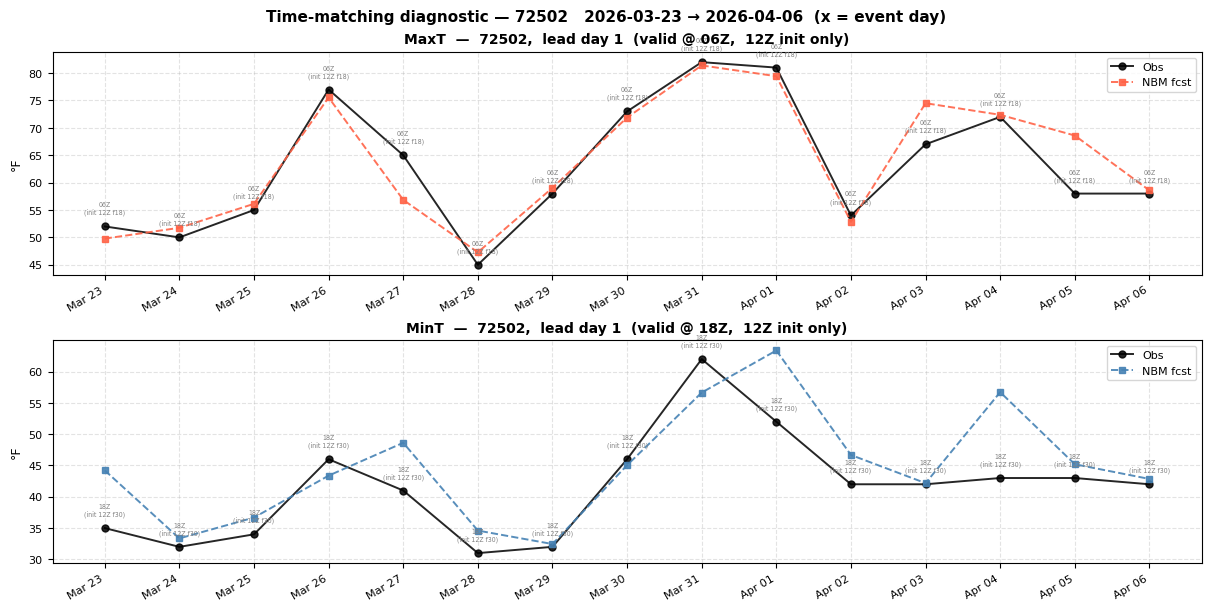


Matched table — 72502, lead_day=1, 12Z init only:
     maxt_fcst_period  maxt_f_hour  maxt_obs_f  maxt_fcst_f  maxt_err       date      mint_fcst_period  mint_f_hour  mint_obs_f  mint_fcst_f  mint_err
03-23 12Z → 03-24 06Z           18        52.0         49.8      -2.2 2026-03-23 03-22 12Z → 03-23 18Z           30        35.0         44.2       9.2
03-24 12Z → 03-25 06Z           18        50.0         51.8       1.8 2026-03-24 03-23 12Z → 03-24 18Z           30        32.0         33.4       1.4
03-25 12Z → 03-26 06Z           18        55.0         56.1       1.1 2026-03-25 03-24 12Z → 03-25 18Z           30        34.0         36.7       2.7
03-26 12Z → 03-27 06Z           18        77.0         75.6      -1.5 2026-03-26 03-25 12Z → 03-26 18Z           30        46.0         43.4      -2.6
03-27 12Z → 03-28 06Z           18        65.0         56.8      -8.1 2026-03-27 03-26 12Z → 03-27 18Z           30        41.0         48.6       7.6
03-28 12Z → 03-29 06Z           18        4

In [56]:
VAR_HOURS = {'maxt': 30, 'mint': 18}  # hours from event day midnight to valid_time

# ── Auto-select a random station and ≤15-day window ───────────────────────
_rng = np.random.default_rng()
_candidates = (
    maxt_paired[maxt_paired['lead_day'] == DIAG_LEAD]
    .groupby('station')['valid_time']
    .agg(['min', 'max'])
    .reset_index()
)
_candidates['span'] = (_candidates['max'] - _candidates['min']).dt.days + 1
_candidates = _candidates[_candidates['span'] >= 1].reset_index(drop=True)
_pick        = _candidates.sample(1, random_state=int(_rng.integers(1e6))).iloc[0]
DIAG_STATION = _pick['station']
_win_days    = min(15, int(_pick['span']))
_win_start   = _pick['min'] + pd.Timedelta(
    days=int(_rng.integers(0, max(1, int(_pick['span']) - _win_days + 1)))
)
DIAG_START = str(_win_start.date())
DIAG_END   = str((_win_start + pd.Timedelta(days=_win_days - 1)).date())
print(f"Auto-selected: station={DIAG_STATION}  {DIAG_START} → {DIAG_END}  "
      f"(lead day {DIAG_LEAD}, init {DIAG_INIT_HOUR:02d}Z)")


def _window(df, station, start, end, lead, var_offset_h, init_hour=None):
    """
    Filter a paired DataFrame for one station/lead/init cycle.
    Adds 'event_day' column derived from valid_time − var_offset_h.
    """
    df2 = df.copy()
    df2['event_day'] = (
        pd.to_datetime(df2['valid_time']) - pd.Timedelta(hours=var_offset_h)
    ).dt.normalize()

    mask = (
        (df2['station']   == station) &
        (df2['lead_day']  == lead) &
        (df2['event_day'] >= pd.Timestamp(start)) &
        (df2['event_day'] <= pd.Timestamp(end))
    )
    if init_hour is not None:
        mask &= (pd.to_datetime(df2['init_time']).dt.hour == init_hour)
    return df2[mask].sort_values('event_day').reset_index(drop=True)


mx = _window(maxt_paired, DIAG_STATION, DIAG_START, DIAG_END,
             DIAG_LEAD, VAR_HOURS['maxt'], DIAG_INIT_HOUR)
mn = _window(mint_paired, DIAG_STATION, DIAG_START, DIAG_END,
             DIAG_LEAD, VAR_HOURS['mint'], DIAG_INIT_HOUR)

init_label = f"{DIAG_INIT_HOUR:02d}Z init only" if DIAG_INIT_HOUR is not None else "all init cycles"
print(f"Station : {DIAG_STATION}   Lead day : {DIAG_LEAD}   ({init_label})")

for name, df in [('MaxT', mx), ('MinT', mn)]:
    n_ed, n_rows = df['event_day'].nunique(), len(df)
    dup_msg = (f"  ⚠  {n_rows - n_ed} duplicate event_days — try DIAG_INIT_HOUR=12 or =0"
               if n_rows > n_ed else "  ✓ no duplicates")
    print(f"  {name}: {n_rows} rows | {n_ed} unique event days{dup_msg}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

for ax, df, var_lbl, utc_hr, color_fcst in [
    (axes[0], mx, 'MaxT', 6,  'tomato'),
    (axes[1], mn, 'MinT', 18, 'steelblue'),
]:
    ax.plot(df['event_day'], df['obs_f'],
            'o-', color='black', ms=5, lw=1.4, alpha=0.85, label='Obs', zorder=3)
    ax.plot(df['event_day'], df['fcst_f'],
            's--', color=color_fcst, ms=5, lw=1.4, alpha=0.9, label='NBM fcst', zorder=3)
    ax.set_title(
        f'{var_lbl}  —  {DIAG_STATION},  lead day {DIAG_LEAD}  '
        f'(valid @ {utc_hr:02d}Z,  {init_label})',
        fontsize=10, fontweight='bold')
    ax.set_ylabel('°F', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(ls='--', alpha=0.35)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    for _, row in df.drop_duplicates('event_day').iterrows():
        init_hr = pd.to_datetime(row['init_time']).hour
        vt      = pd.to_datetime(row['valid_time'])
        ax.annotate(
            f"{vt.strftime('%HZ')}\n(init {init_hr:02d}Z f{int(row['lead_hour'])})",
            xy=(row['event_day'], row['obs_f']),
            xytext=(0, 8), textcoords='offset points',
            fontsize=4.5, color='gray', ha='center', linespacing=1.3)

fig.suptitle(
    f'Time-matching diagnostic — {DIAG_STATION}   {DIAG_START} → {DIAG_END}  (x = event day)',
    fontsize=11, fontweight='bold')
plt.show()

# ── Matched table ─────────────────────────────────────────────────────────
def _tbl_half(df, prefix, obs_hour_offset):
    out = df[['valid_time', 'init_time', 'lead_hour', 'fcst_f', 'obs_f']].copy()
    vt  = pd.to_datetime(out['valid_time'])
    it  = pd.to_datetime(out['init_time'])
    out[f'{prefix}_fcst_period'] = it.dt.strftime('%m-%d %HZ') + ' → ' + vt.dt.strftime('%m-%d %HZ')
    out[f'{prefix}_f_hour']      = out['lead_hour'].astype(int)
    out[f'{prefix}_obs_f']       = out['obs_f'].round(1)
    out[f'{prefix}_fcst_f']      = out['fcst_f'].round(1)
    out[f'{prefix}_err']         = (out['fcst_f'] - out['obs_f']).round(1)
    out['date']                  = (vt - pd.Timedelta(hours=obs_hour_offset)).dt.normalize()
    return out.drop(columns=['valid_time', 'init_time', 'lead_hour', 'fcst_f', 'obs_f'])


tbl = (
    _tbl_half(mx, 'maxt', VAR_HOURS['maxt'])
    .merge(_tbl_half(mn, 'mint', VAR_HOURS['mint']), on='date', how='outer')
    .sort_values('date')
)
tbl['date'] = tbl['date'].dt.strftime('%Y-%m-%d')
print(f"\nMatched table — {DIAG_STATION}, lead_day={DIAG_LEAD}, {init_label}:")
print(tbl.to_string(index=False))


## 5. Deterministic Skill
MAE, RMSE, and bias aggregated across all paired station-days.

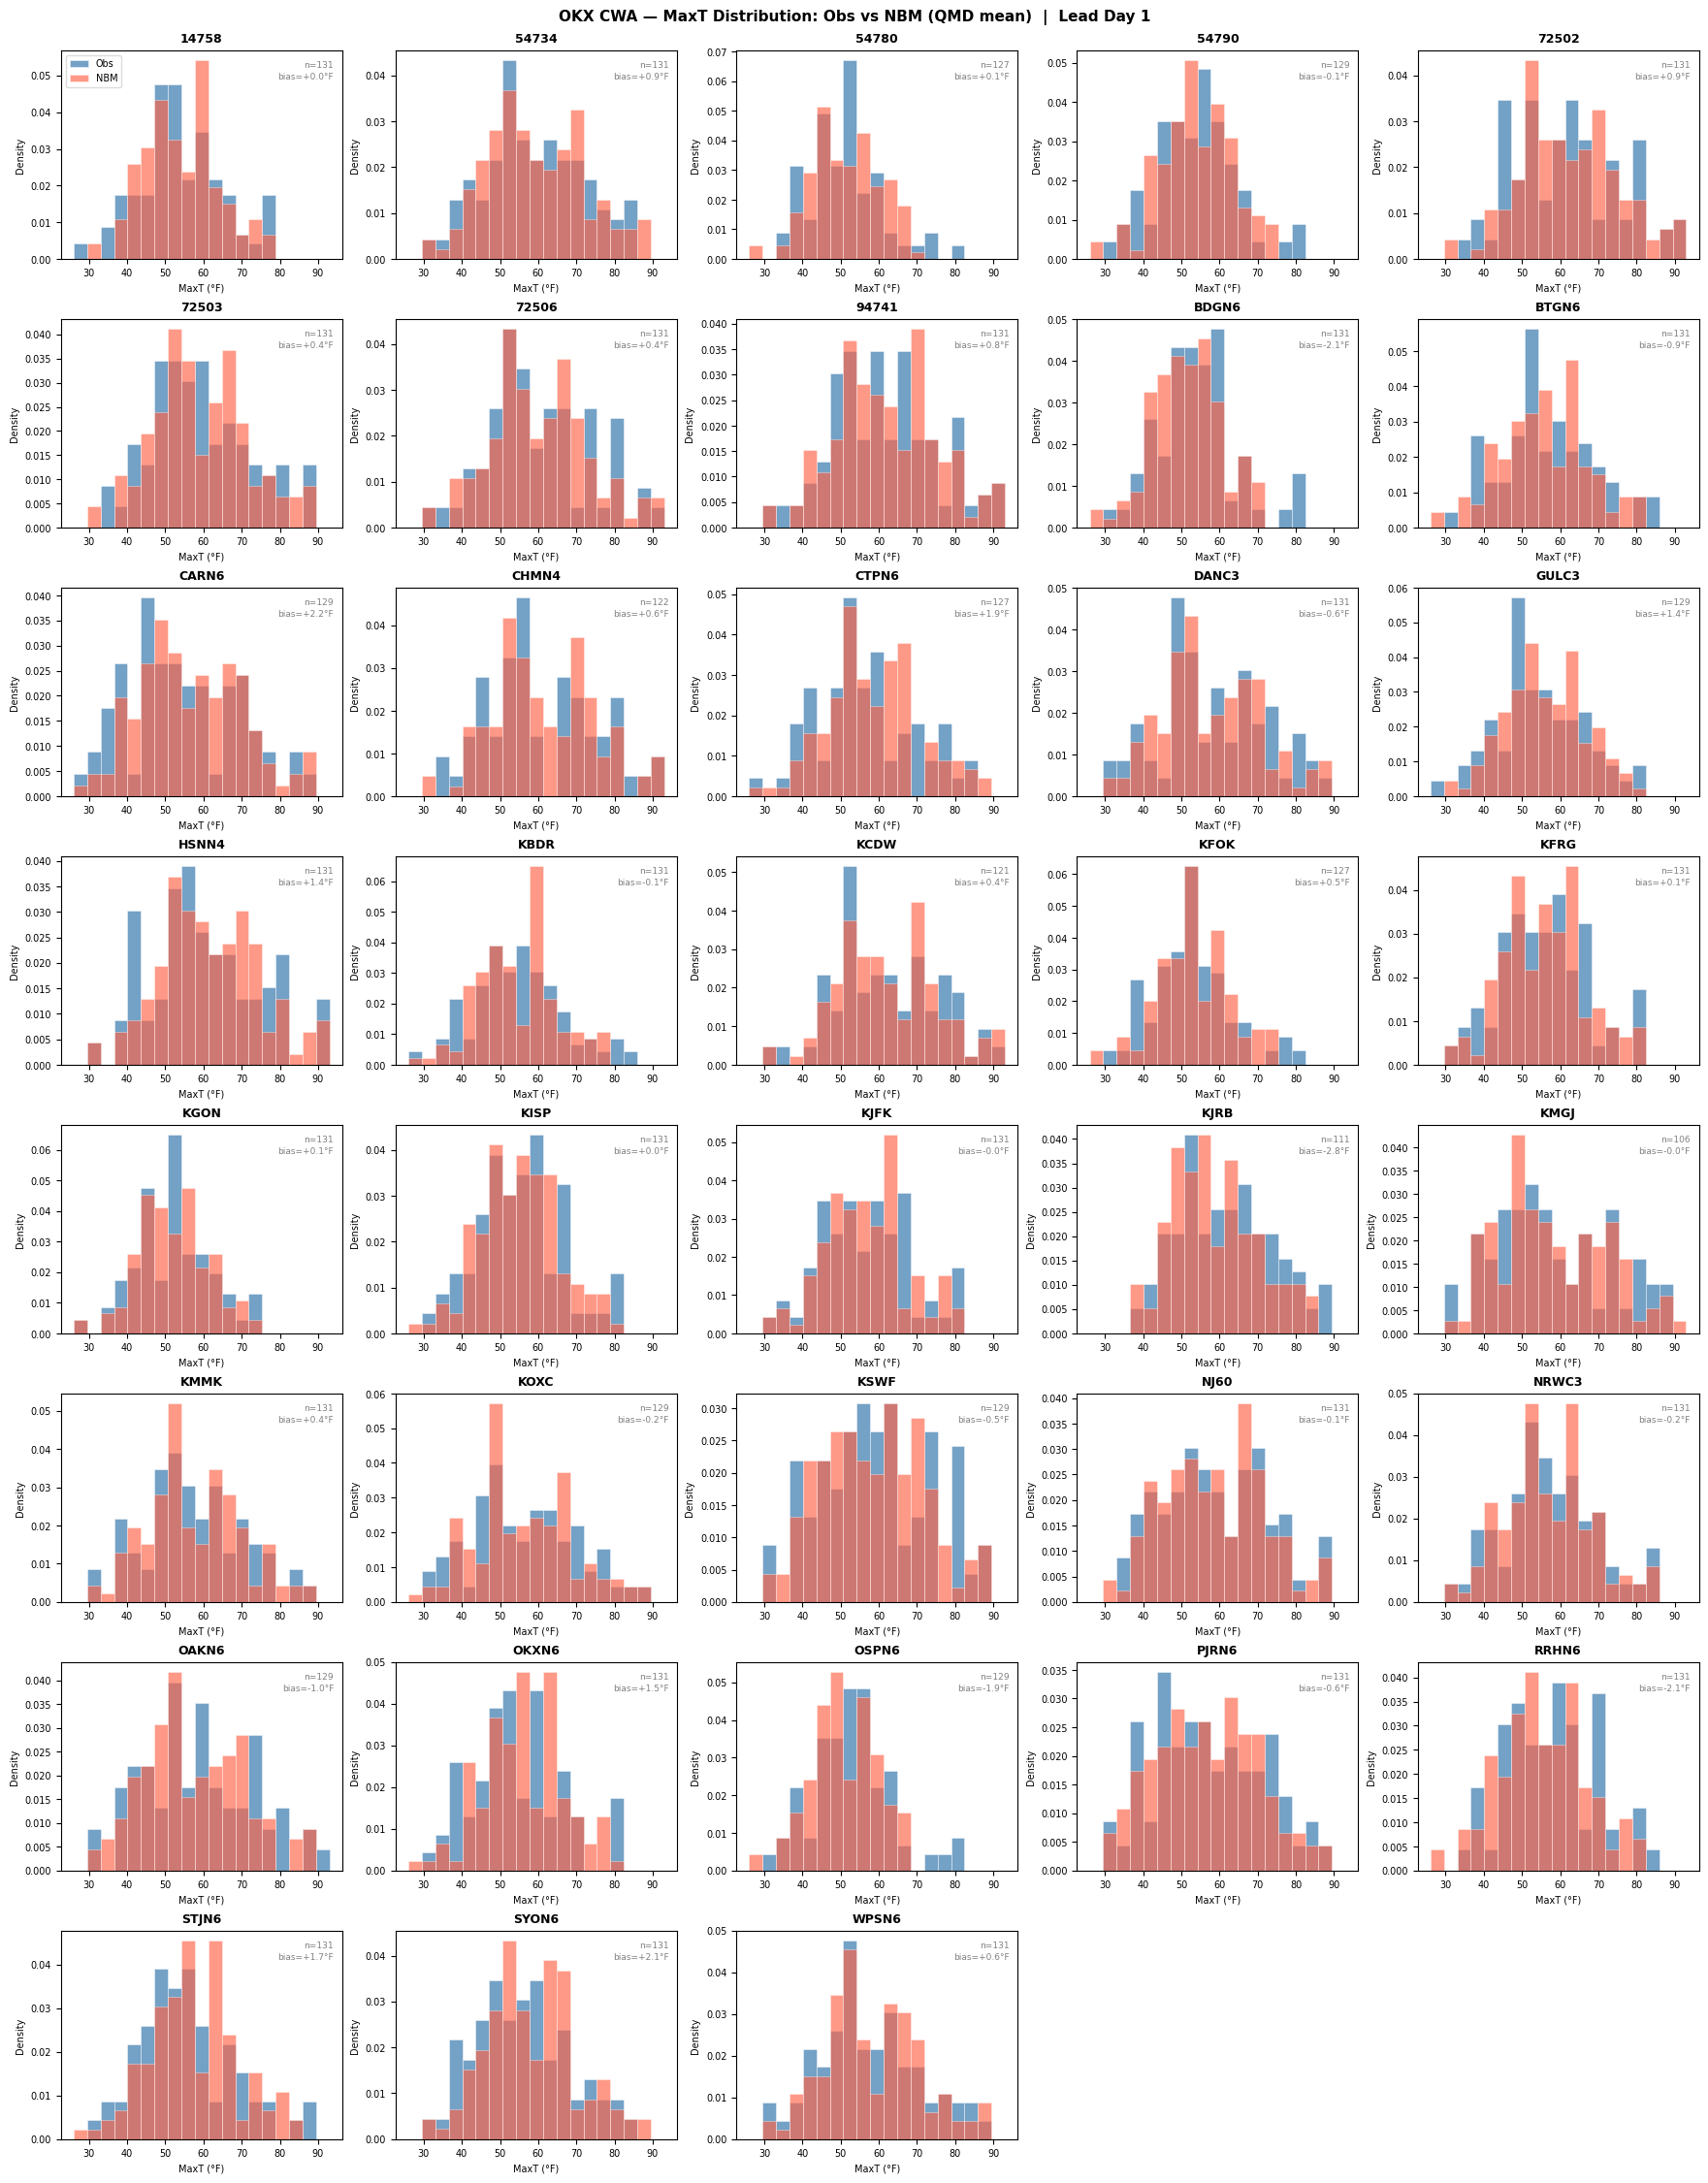

In [46]:
# ── Per-station MaxT distribution histogram ───────────────────────────────
subset        = maxt_paired[maxt_paired['lead_day'] == LEAD_DAY]
stations_order = sorted(subset['station'].dropna().unique())
n     = len(stations_order)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.5, nrows * 2.8),
                          constrained_layout=True)
axes_flat = axes.flatten()

all_obs  = subset['obs_f'].dropna()
all_fcst = subset['fcst_f'].dropna()
bins     = np.linspace(float(min(all_obs.min(), all_fcst.min())),
                       float(max(all_obs.max(), all_fcst.max())), 20)

for i, stid in enumerate(stations_order):
    ax   = axes_flat[i]
    s    = subset[subset['station'] == stid]
    obs  = s['obs_f'].dropna()
    fcst = s['fcst_f'].dropna()
    hist_kw = dict(bins=bins, density=True, edgecolor='white', linewidth=0.4)
    ax.hist(obs,  **hist_kw, color='steelblue', alpha=0.75, label='Obs')
    ax.hist(fcst, **hist_kw, color='tomato',    alpha=0.65, label='NBM')
    bias = float((fcst.values - obs.values).mean()) if len(obs) == len(fcst) else float('nan')
    ax.set_title(stid, fontsize=9, fontweight='bold')
    ax.set_xlabel('MaxT (°F)', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.text(0.97, 0.95, f'n={len(obs)}\nbias={bias:+.1f}°F',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=6.5, color='gray', linespacing=1.4)

axes_flat[0].legend(fontsize=7, framealpha=0.7)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    f'{CWA} CWA — MaxT Distribution: Obs vs NBM (QMD mean)  |  Lead Day {LEAD_DAY}',
    fontsize=11, fontweight='bold')
plt.show()

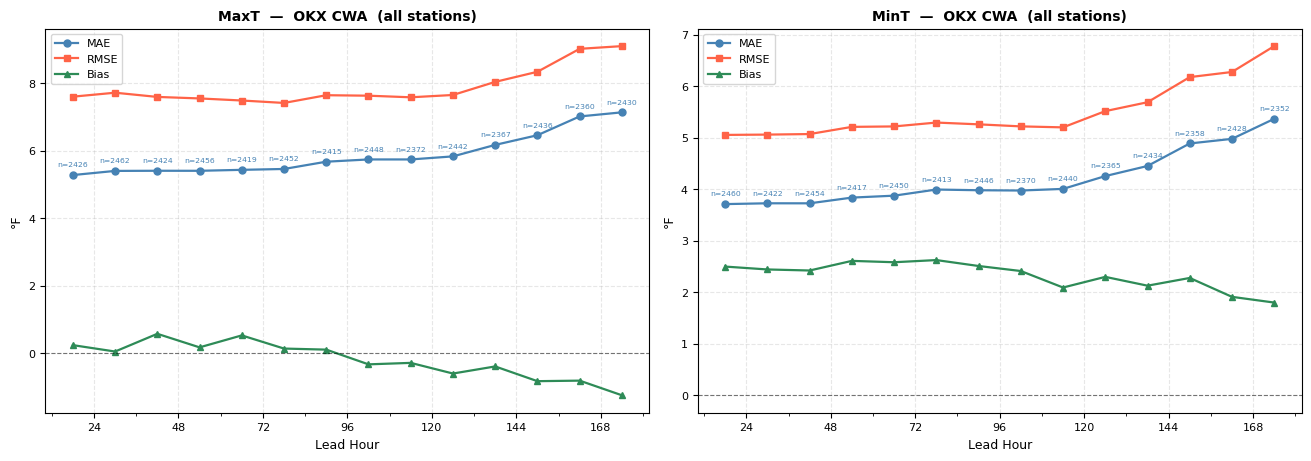

In [47]:
# ── Aggregate skill by lead hour ──────────────────────────────────────────
def skill_by_lead(paired):
    """MAE, RMSE, and bias aggregated across all stations per lead_hour."""
    err = paired['fcst_f'] - paired['obs_f']
    return (
        paired.assign(err=err)
        .groupby('lead_hour')
        .agg(
            mae  =('err', lambda e: np.abs(e).mean()),
            rmse =('err', lambda e: np.sqrt((e ** 2).mean())),
            bias =('err', 'mean'),
            n    =('err', 'count'),
        )
        .reset_index()
    )


stats_maxt = skill_by_lead(maxt_paired)
stats_mint = skill_by_lead(mint_paired)

METRICS = [
    ('mae',  'MAE',  'steelblue', '-o'),
    ('rmse', 'RMSE', 'tomato',    '-s'),
    ('bias', 'Bias', 'seagreen',  '-^'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True, sharey=False)

for ax, stats, title in zip(axes, [stats_maxt, stats_mint], ['MaxT', 'MinT']):
    for col, label, color, fmt in METRICS:
        ax.plot(stats['lead_hour'], stats[col], fmt,
                color=color, ms=5, lw=1.6, label=label)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{title}  —  {CWA} CWA  (all stations)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lead Hour', fontsize=9)
    ax.set_ylabel('°F', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(24))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(12))
    ax.tick_params(labelsize=8)
    ax.grid(axis='both', which='major', ls='--', alpha=0.3)
    ax.legend(fontsize=8)
    for _, row in stats.iterrows():
        ax.annotate(f"n={int(row['n'])}",
                    xy=(row['lead_hour'], row['mae']),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=5.5, color='steelblue')

plt.show()

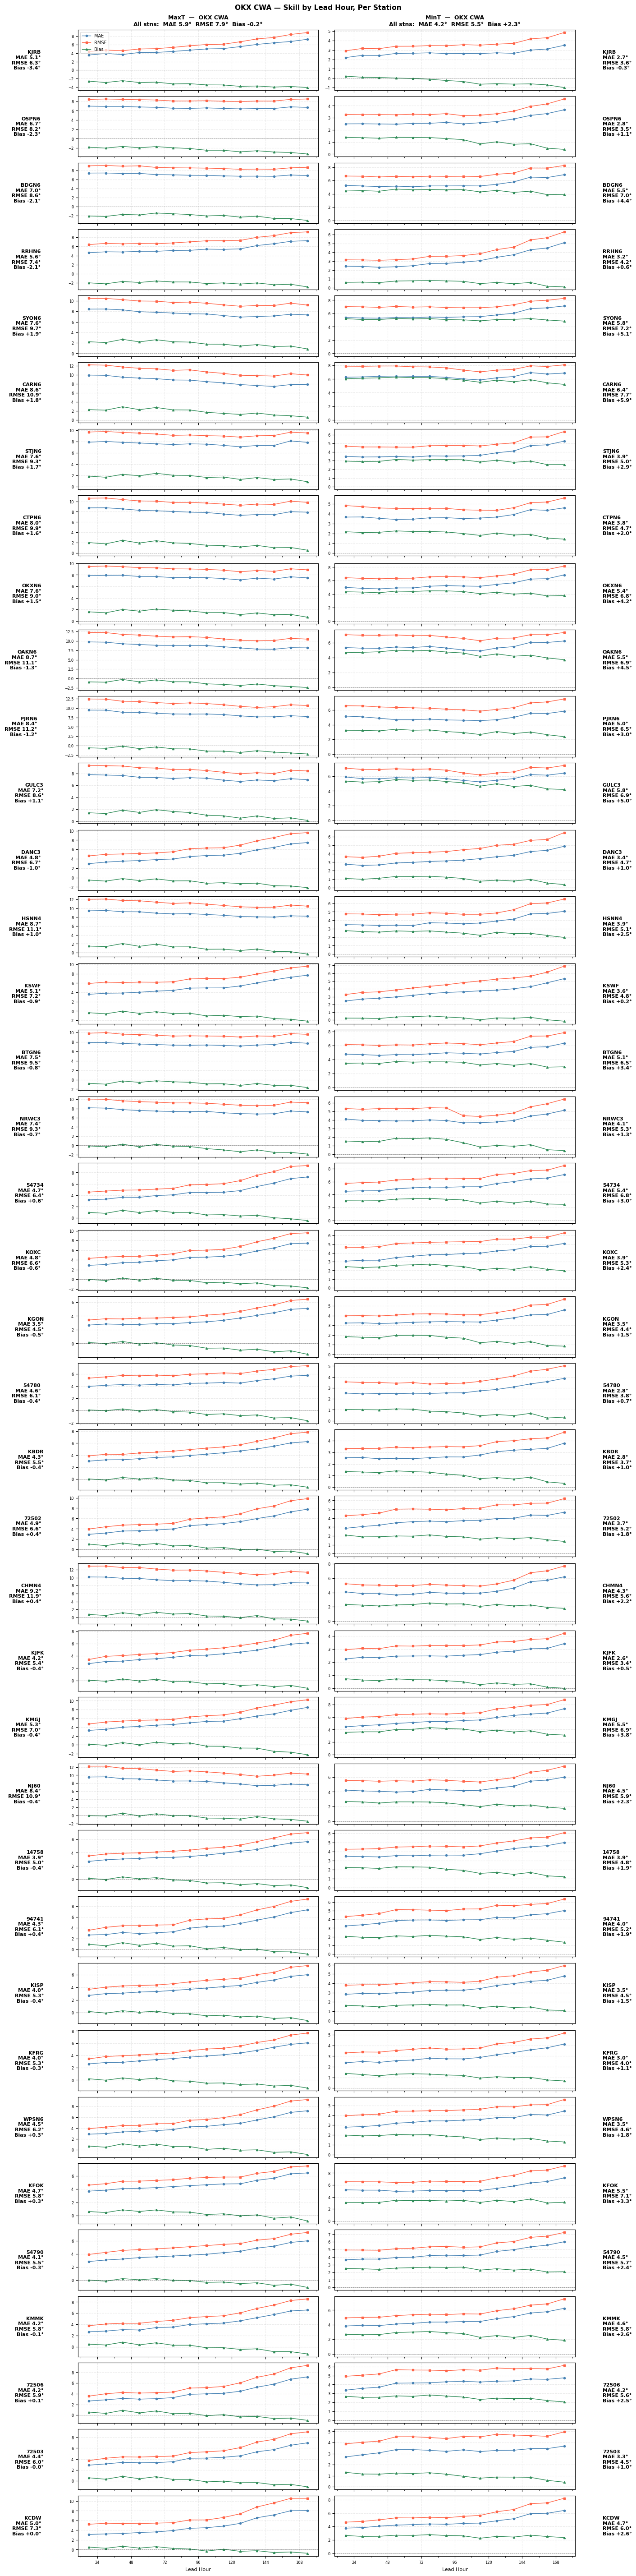

In [48]:
# ── Per-station skill vs lead hour ────────────────────────────────────────
def skill_by_lead_per_station(paired):
    """MAE, RMSE, and bias per station per lead_hour."""
    err = paired['fcst_f'] - paired['obs_f']
    return (
        paired.assign(err=err)
        .groupby(['station', 'lead_hour'])
        .agg(
            mae  =('err', lambda e: np.abs(e).mean()),
            rmse =('err', lambda e: np.sqrt((e ** 2).mean())),
            bias =('err', 'mean'),
            n    =('err', 'count'),
        )
        .reset_index()
    )


def _stn_agg(paired):
    """Aggregate skill per station across all lead hours."""
    err = paired['fcst_f'] - paired['obs_f']
    return (
        paired.assign(err=err)
        .groupby('station')
        .agg(
            mae  =('err', lambda e: np.abs(e).mean()),
            rmse =('err', lambda e: np.sqrt((e ** 2).mean())),
            bias =('err', 'mean'),
        )
        .reset_index()
        .set_index('station')
    )


def _global_agg(paired):
    """All-station all-lead aggregate stats."""
    err = paired['fcst_f'] - paired['obs_f']
    return dict(
        mae  = float(np.abs(err).mean()),
        rmse = float(np.sqrt((err ** 2).mean())),
        bias = float(err.mean()),
    )


stn_stats_maxt = skill_by_lead_per_station(maxt_paired)
stn_stats_mint = skill_by_lead_per_station(mint_paired)
stn_agg_maxt   = _stn_agg(maxt_paired)
stn_agg_mint   = _stn_agg(mint_paired)
glob_maxt      = _global_agg(maxt_paired)
glob_mint      = _global_agg(mint_paired)

# Sort by absolute MaxT bias, largest first
all_stns = set(stn_stats_maxt['station'].unique()) | set(stn_stats_mint['station'].unique())
stations_order = sorted(
    all_stns,
    key=lambda s: abs(stn_agg_maxt.loc[s, 'bias']) if s in stn_agg_maxt.index else 0.0,
    reverse=True,
)
n_stns = len(stations_order)

METRICS = [
    ('mae',  'MAE',  'steelblue', 'o-', 3),
    ('rmse', 'RMSE', 'tomato',    's-', 3),
    ('bias', 'Bias', 'seagreen',  '^-', 3),
]

fig, axes = plt.subplots(n_stns, 2,
                          figsize=(14, n_stns * 1.5),
                          constrained_layout=True,
                          sharex=True, sharey=False)


def _stn_label(stid, stn_agg):
    if stid in stn_agg.index:
        r = stn_agg.loc[stid]
        return f"{stid}\nMAE {r['mae']:.1f}°\nRMSE {r['rmse']:.1f}°\nBias {r['bias']:+.1f}°"
    return stid


for row_i, stid in enumerate(stations_order):
    for col_i, (stn_stats, stn_agg) in enumerate([
        (stn_stats_maxt, stn_agg_maxt),
        (stn_stats_mint, stn_agg_mint),
    ]):
        ax = axes[row_i, col_i]
        s  = stn_stats[stn_stats['station'] == stid]
        if not s.empty:
            for col, label, color, fmt, ms in METRICS:
                ax.plot(s['lead_hour'], s[col], fmt,
                        color=color, ms=ms, lw=1.0,
                        label=label if row_i == 0 else None)
            ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(24))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(12))
        ax.tick_params(labelsize=6)
        ax.grid(axis='both', which='major', ls='--', alpha=0.25)
        if col_i == 0:
            ax.set_ylabel(_stn_label(stid, stn_agg_maxt),
                          fontsize=8, fontweight='bold', rotation=0,
                          ha='right', va='center', labelpad=44)
        else:
            ax.yaxis.set_label_position('right')
            ax.set_ylabel(_stn_label(stid, stn_agg_mint),
                          fontsize=8, fontweight='bold', rotation=0,
                          ha='left', va='center', labelpad=44)


def _col_title(var_name, g):
    return (f'{var_name}  —  {CWA} CWA\n'
            f'All stns:  MAE {g["mae"]:.1f}°  RMSE {g["rmse"]:.1f}°  Bias {g["bias"]:+.1f}°')


axes[0, 0].set_title(_col_title('MaxT', glob_maxt), fontsize=9, fontweight='bold')
axes[0, 1].set_title(_col_title('MinT', glob_mint), fontsize=9, fontweight='bold')
for ax in axes[-1]:
    ax.set_xlabel('Lead Hour', fontsize=8)
axes[0, 0].legend(fontsize=7, loc='upper left', framealpha=0.7)

fig.suptitle(f'{CWA} CWA — Skill by Lead Hour, Per Station', fontsize=11, fontweight='bold')
plt.show()

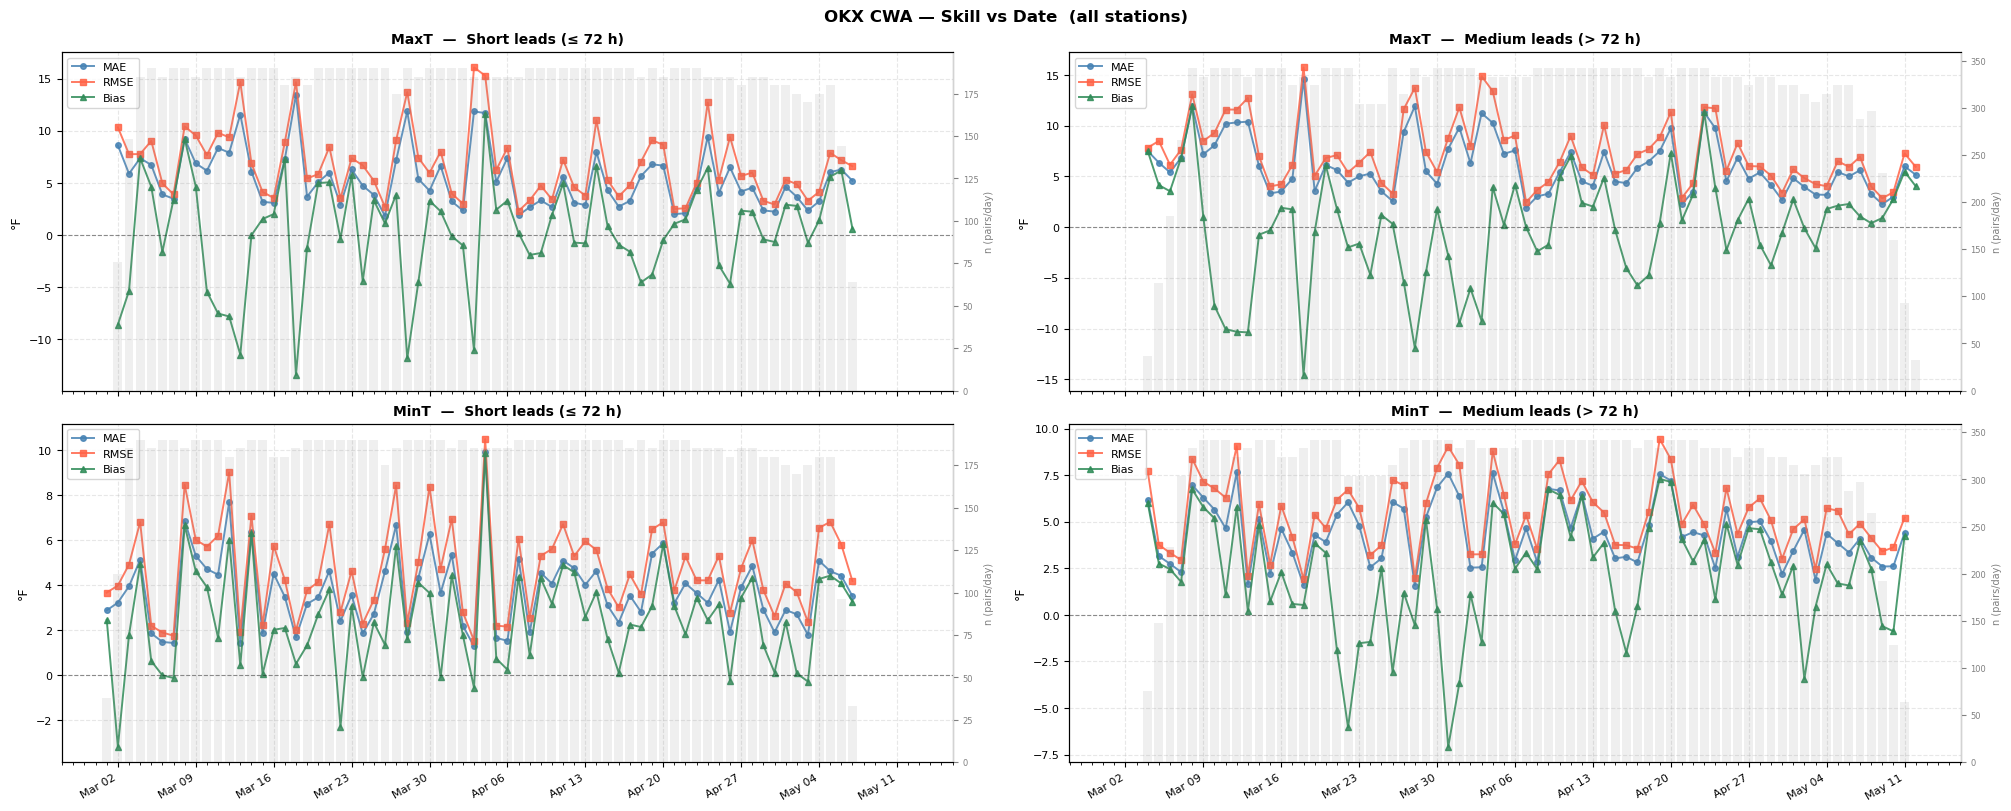

In [49]:
# ── Skill vs date (short vs medium leads) ────────────────────────────────
def skill_by_date(paired, lh_min=None, lh_max=None):
    """
    Average errors across all stations per valid-time date.
    lh_min / lh_max : inclusive lower / exclusive upper lead_hour bound.
    """
    df = paired.copy()
    if lh_min is not None:
        df = df[df['lead_hour'] > lh_min]
    if lh_max is not None:
        df = df[df['lead_hour'] <= lh_max]
    df['err']  = df['fcst_f'] - df['obs_f']
    df['date'] = df['valid_time'].dt.normalize()
    return (
        df.groupby('date')
        .agg(
            mae  =('err', lambda e: np.abs(e).mean()),
            rmse =('err', lambda e: np.sqrt((e ** 2).mean())),
            bias =('err', 'mean'),
            n    =('err', 'count'),
        )
        .reset_index()
    )


panels = [
    (maxt_paired, None, 72,  'MaxT', 'Short leads (≤ 72 h)'),
    (maxt_paired, 72,  None, 'MaxT', 'Medium leads (> 72 h)'),
    (mint_paired, None, 72,  'MinT', 'Short leads (≤ 72 h)'),
    (mint_paired, 72,  None, 'MinT', 'Medium leads (> 72 h)'),
]

METRICS = [
    ('mae',  'MAE',  'steelblue', '-o', 4),
    ('rmse', 'RMSE', 'tomato',    '-s', 4),
    ('bias', 'Bias', 'seagreen',  '-^', 4),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 8), constrained_layout=True, sharex=True)

for (paired, lh_min, lh_max, var_lbl, lead_lbl), ax in zip(panels, axes.flat):
    ts = skill_by_date(paired, lh_min, lh_max)
    for col, label, color, fmt, ms in METRICS:
        ax.plot(ts['date'], ts[col], fmt,
                color=color, ms=ms, lw=1.4, alpha=0.85, label=label)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(f'{var_lbl}  —  {lead_lbl}', fontsize=10, fontweight='bold')
    ax.set_ylabel('°F', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis='both', which='major', ls='--', alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
    ax2 = ax.twinx()
    ax2.bar(ts['date'], ts['n'], width=0.8, color='gray', alpha=0.12, zorder=0)
    ax2.set_ylabel('n (pairs/day)', fontsize=7, color='gray')
    ax2.tick_params(labelsize=6, colors='gray')
    ax2.spines['right'].set_color('lightgray')

for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'{CWA} CWA — Skill vs Date  (all stations)', fontsize=12, fontweight='bold')
plt.show()

## 6. Probabilistic Verification — Percentile Reliability
Melt the percentile columns (`nbm_p5`–`nbm_p100`) to long form, pair with obs,
and plot reliability diagrams. A perfectly calibrated system lies on the 1:1 diagonal.

In [50]:
# Percentile column names → integer percentile labels
PERC_COLS = {
    'nbm_p5': 5, 'nbm_p10': 10, 'nbm_p25': 25, 'nbm_p50': 50,
    'nbm_p75': 75, 'nbm_p90': 90, 'nbm_p95': 95, 'nbm_p100': 100,
}


def _build_perc_paired(df: pd.DataFrame, variable: str) -> pd.DataFrame:
    """
    Melt percentile forecast columns and compute the 'below' flag
    (obs < percentile threshold) for reliability scoring.
    """
    sub = (
        df[df['variable'] == variable]
        [['stid', 'init_time', 'lead_hour', 'valid_time', 'lead_day', 'obs_value']
         + list(PERC_COLS)]
        .rename(columns={'stid': 'station', 'obs_value': 'obs_f'})
        .dropna(subset=['obs_f'])
    )
    melted = sub.melt(
        id_vars=['station', 'init_time', 'lead_hour', 'valid_time', 'lead_day', 'obs_f'],
        value_vars=list(PERC_COLS),
        var_name='perc_col', value_name='fcst_f',
    )
    melted['percentile'] = melted['perc_col'].map(PERC_COLS)
    melted = melted.dropna(subset=['fcst_f']).drop(columns='perc_col')
    melted['below'] = (melted['obs_f'] < melted['fcst_f']).astype(float)
    return melted.sort_values(['station', 'init_time', 'lead_hour', 'percentile']).reset_index(drop=True)


maxt_perc_paired = _build_perc_paired(raw, 'maxt')
mint_perc_paired = _build_perc_paired(raw, 'mint')

for name, df in [('maxt_perc_paired', maxt_perc_paired), ('mint_perc_paired', mint_perc_paired)]:
    print(f"{name}: {len(df):,} rows | {df['station'].nunique()} stations | "
          f"percentiles: {sorted(df['percentile'].unique())}")

maxt_perc_paired: 271,272 rows | 38 stations | percentiles: [5, 10, 25, 50, 75, 90, 95, 100]
mint_perc_paired: 270,472 rows | 38 stations | percentiles: [5, 10, 25, 50, 75, 90, 95, 100]


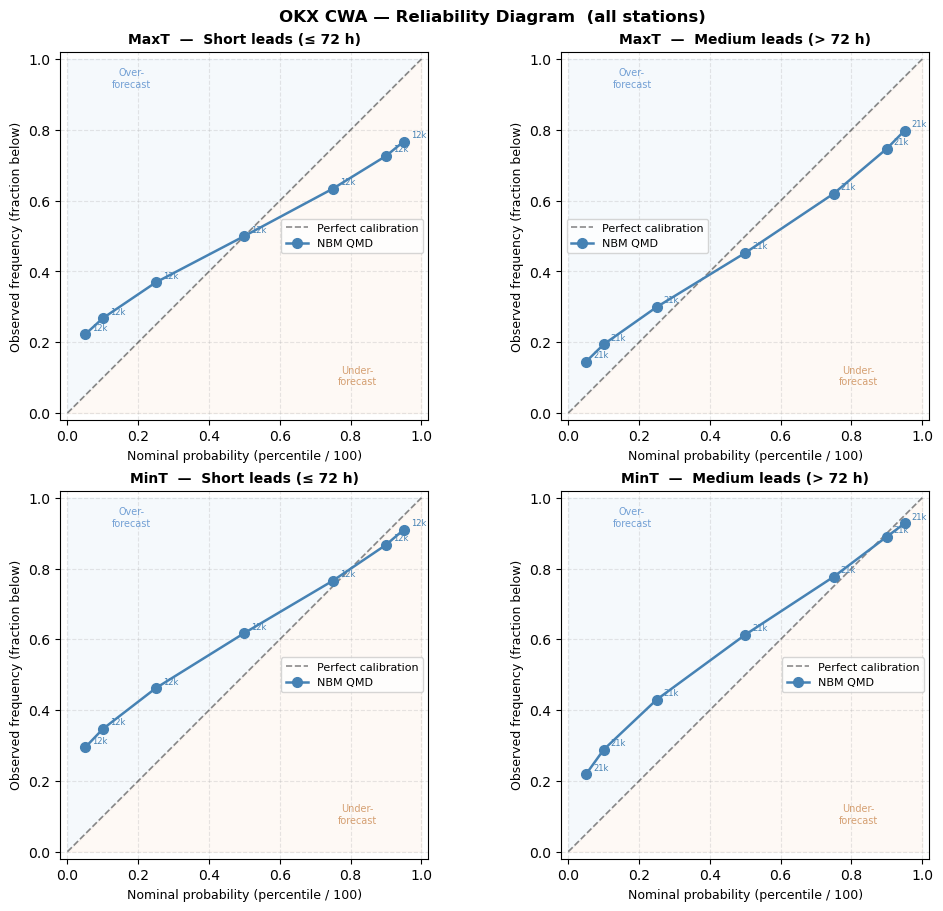

In [51]:
def reliability(paired, lh_min=None, lh_max=None):
    """
    For each percentile, compute the fraction of cases where obs < fcst threshold.
    A perfectly calibrated system lies on the 1:1 diagonal.
    """
    df = paired[~paired['percentile'].isin(SKIP_PERCS)].copy()
    if lh_min is not None:
        df = df[df['lead_hour'] > lh_min]
    if lh_max is not None:
        df = df[df['lead_hour'] <= lh_max]
    return (
        df.groupby('percentile')
        .agg(obs_freq=('below', 'mean'), n=('below', 'count'))
        .reset_index()
        .assign(nominal=lambda d: d['percentile'] / 100)
    )


panels = [
    (maxt_perc_paired, None, 72,  'MaxT', 'Short leads (≤ 72 h)'),
    (maxt_perc_paired, 72,  None, 'MaxT', 'Medium leads (> 72 h)'),
    (mint_perc_paired, None, 72,  'MinT', 'Short leads (≤ 72 h)'),
    (mint_perc_paired, 72,  None, 'MinT', 'Medium leads (> 72 h)'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)

for (paired_data, lh_min, lh_max, var_lbl, lead_lbl), ax in zip(panels, axes.flat):
    rel = reliability(paired_data, lh_min, lh_max)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.45, label='Perfect calibration')
    ax.plot(rel['nominal'], rel['obs_freq'],
            'o-', color='steelblue', ms=7, lw=1.8, zorder=3, label='NBM QMD')
    ax.fill_between([0, 1], [0, 1], 1, color='#d9eaf7', alpha=0.25, zorder=0)
    ax.fill_between([0, 1], 0, [0, 1], color='#fde8d8', alpha=0.25, zorder=0)
    ax.text(0.82, 0.08, 'Under-\nforecast', ha='center', fontsize=7, color='#c47a3b', alpha=0.7)
    ax.text(0.18, 0.92, 'Over-\nforecast',  ha='center', fontsize=7, color='#3b7ac4', alpha=0.7)
    for _, row in rel.iterrows():
        n_lbl = f"{int(row['n']) // 1000}k" if row['n'] >= 1000 else str(int(row['n']))
        ax.annotate(n_lbl, xy=(row['nominal'], row['obs_freq']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=6, color='steelblue')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Nominal probability (percentile / 100)', fontsize=9)
    ax.set_ylabel('Observed frequency (fraction below)', fontsize=9)
    ax.set_title(f'{var_lbl}  —  {lead_lbl}', fontsize=10, fontweight='bold')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(ls='--', alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(f'{CWA} CWA — Reliability Diagram  (all stations)', fontsize=12, fontweight='bold')
plt.show()

## 7. Probabilistic Verification — Threshold Exceedance
Use the pre-computed `nbm_prob_gt_*` columns (stored as 0–100; normalised to 0–1 here)
to build threshold-exceedance reliability diagrams.
X-axis: NBM issued probability. Y-axis: observed exceedance rate. Perfect calibration = 1:1 diagonal.

In [52]:
# Threshold probability columns → threshold value in °F
PROB_COLS = {
    'nbm_prob_gt_080f': 80,
    'nbm_prob_gt_090f': 90,
    'nbm_prob_gt_100f': 100,
    'nbm_prob_gt_110f': 110,
    'nbm_prob_gt_120f': 120,
}


def _build_prob_paired(df: pd.DataFrame, variable: str) -> pd.DataFrame:
    """
    Melt threshold probability columns, normalise 0-100 → 0-1, and compute
    the 'obs_above' flag (obs > threshold) for reliability scoring.
    """
    avail_cols = [c for c in PROB_COLS if c in df.columns]
    sub = (
        df[df['variable'] == variable]
        [['stid', 'init_time', 'lead_hour', 'valid_time', 'lead_day', 'obs_value'] + avail_cols]
        .rename(columns={'stid': 'station', 'obs_value': 'obs_f'})
        .dropna(subset=['obs_f'])
    )
    melted = sub.melt(
        id_vars=['station', 'init_time', 'lead_hour', 'valid_time', 'lead_day', 'obs_f'],
        value_vars=avail_cols,
        var_name='prob_col', value_name='prob_raw',
    )
    melted['threshold_f'] = melted['prob_col'].map(PROB_COLS)
    melted['prob']        = melted['prob_raw'] / 100.0   # 0-100 → 0-1
    melted = melted.dropna(subset=['prob']).drop(columns='prob_col')
    melted['obs_above'] = (melted['obs_f'] > melted['threshold_f']).astype(float)
    return melted.sort_values(['station', 'init_time', 'lead_hour', 'threshold_f']).reset_index(drop=True)


maxt_prob_paired = _build_prob_paired(raw, 'maxt')
mint_prob_paired = _build_prob_paired(raw, 'mint')

for name, df in [('maxt_prob_paired', maxt_prob_paired), ('mint_prob_paired', mint_prob_paired)]:
    thresholds = sorted(df['threshold_f'].unique())
    print(f"{name}: {len(df):,} rows | {df['station'].nunique()} stations | "
          f"thresholds: {[int(t) for t in thresholds]}°F")

maxt_prob_paired: 169,545 rows | 38 stations | thresholds: [80, 90, 100, 110, 120]°F
mint_prob_paired: 33,809 rows | 38 stations | thresholds: [80]°F


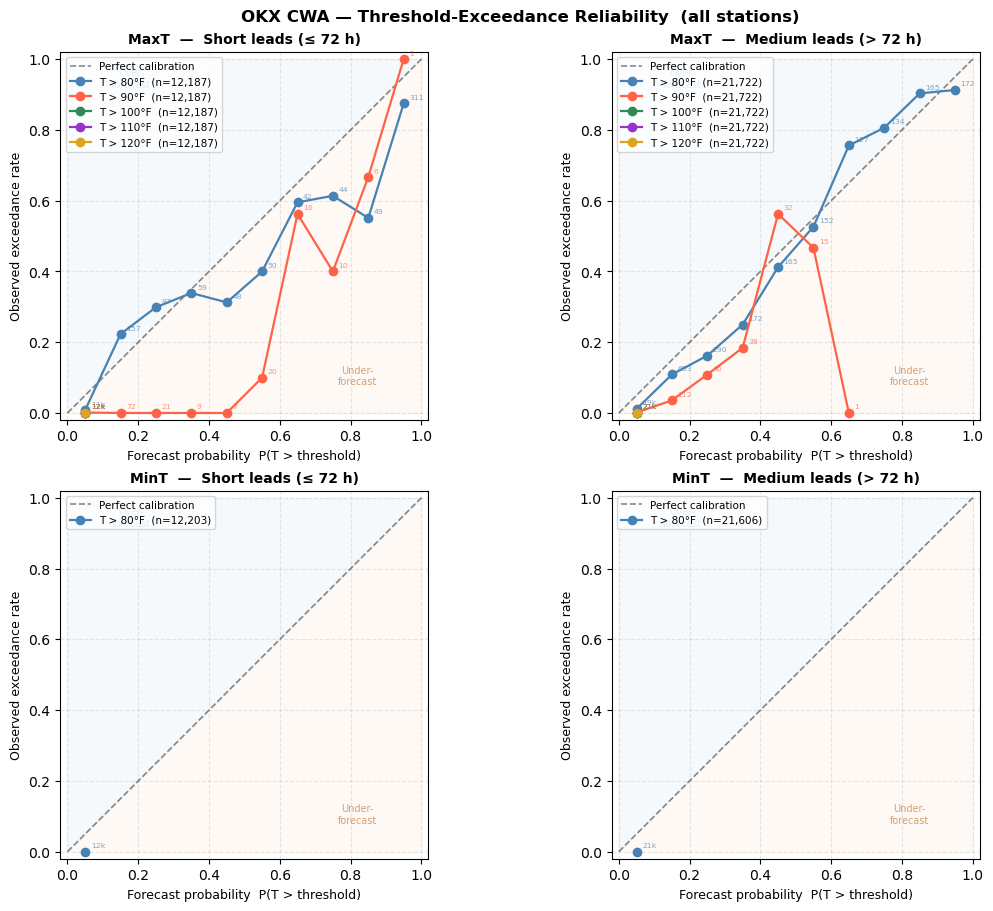

In [53]:
def _reliability_thresh(paired_df, lh_min=None, lh_max=None):
    """Bin by forecast probability; compute observed exceedance rate per threshold."""
    df = paired_df.copy()
    if lh_min is not None:
        df = df[df['lead_hour'] > lh_min]
    if lh_max is not None:
        df = df[df['lead_hour'] <= lh_max]

    rows = []
    for thr_f, grp in df.groupby('threshold_f'):
        bin_idx = np.clip(
            np.digitize(grp['prob'].values, PROB_BINS) - 1,
            0, len(BIN_CENTERS) - 1,
        )
        for b in range(len(BIN_CENTERS)):
            mask = bin_idx == b
            n    = int(mask.sum())
            if n == 0:
                continue
            rows.append({
                'threshold_f': thr_f,
                'bin_center':  BIN_CENTERS[b],
                'obs_freq':    float(grp['obs_above'].values[mask].mean()),
                'n':           n,
            })
    return pd.DataFrame(rows)


panels = [
    (maxt_prob_paired, None, 72,  'MaxT', 'Short leads (≤ 72 h)'),
    (maxt_prob_paired, 72,  None, 'MaxT', 'Medium leads (> 72 h)'),
    (mint_prob_paired, None, 72,  'MinT', 'Short leads (≤ 72 h)'),
    (mint_prob_paired, 72,  None, 'MinT', 'Medium leads (> 72 h)'),
]

COLORS = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'goldenrod']

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

for (p_df, lh_min, lh_max, var_lbl, lead_lbl), ax in zip(panels, axes.flat):
    rel = _reliability_thresh(p_df, lh_min, lh_max)

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.45, label='Perfect calibration')
    ax.fill_between([0, 1], [0, 1], 1, color='#d9eaf7', alpha=0.25, zorder=0)
    ax.fill_between([0, 1], 0, [0, 1], color='#fde8d8', alpha=0.25, zorder=0)
    ax.text(0.82, 0.08, 'Under-\nforecast', ha='center', fontsize=7, color='#c47a3b', alpha=0.7)
    ax.text(0.18, 0.92, 'Over-\nforecast',  ha='center', fontsize=7, color='#3b7ac4', alpha=0.7)

    for thr, color in zip(sorted(rel['threshold_f'].unique()), COLORS):
        sub     = rel[rel['threshold_f'] == thr].sort_values('bin_center')
        n_total = int(sub['n'].sum())
        ax.plot(sub['bin_center'], sub['obs_freq'],
                'o-', color=color, ms=6, lw=1.6, zorder=3,
                label=f'T > {int(thr)}°F  (n={n_total:,})')
        for _, r in sub.iterrows():
            ax.annotate(
                f"{int(r['n']) // 1000}k" if r['n'] >= 1000 else str(int(r['n'])),
                xy=(r['bin_center'], r['obs_freq']),
                xytext=(4, 3), textcoords='offset points',
                fontsize=5.5, color=color, alpha=0.7,
            )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Forecast probability  P(T > threshold)', fontsize=9)
    ax.set_ylabel('Observed exceedance rate', fontsize=9)
    ax.set_title(f'{var_lbl}  —  {lead_lbl}', fontsize=10, fontweight='bold')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(ls='--', alpha=0.3)
    ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle(
    f'{CWA} CWA — Threshold-Exceedance Reliability  (all stations)',
    fontsize=12, fontweight='bold')
plt.show()